In [40]:
import pandas as pd
import numpy as np 
import requests
import zipfile
import io
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [41]:
data = pd.read_csv("https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv")
data.head()

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score,converted
0,paid_ads,NaN,1,79450.0,unemployed,south_america,4,0.94,1
1,social_media,retail,1,46992.0,employed,south_america,1,0.80,0
2,events,healthcare,5,78796.0,unemployed,australia,3,0.69,1
3,paid_ads,retail,2,83843.0,NaN,australia,1,0.87,0
4,referral,education,3,85012.0,self_employed,europe,3,0.62,1


In [42]:
df = data.copy()

In [43]:
df.isnull().sum()

lead_source                 128
industry                    134
number_of_courses_viewed      0
annual_income               181
employment_status           100
location                     63
interaction_count             0
lead_score                    0
converted                     0
dtype: int64

In [44]:
df.dtypes

lead_source                  object
industry                     object
number_of_courses_viewed      int64
annual_income               float64
employment_status            object
location                     object
interaction_count             int64
lead_score                  float64
converted                     int64
dtype: object

In [45]:
categorical = list(df.dtypes[df.dtypes == "object"].index)
numerical = list(df.dtypes[df.dtypes != "object"].index)

In [46]:
df[categorical].isnull().sum()

lead_source          128
industry             134
employment_status    100
location              63
dtype: int64

In [47]:
df[numerical].isnull().sum()

number_of_courses_viewed      0
annual_income               181
interaction_count             0
lead_score                    0
converted                     0
dtype: int64

In [48]:
df[categorical] = df[categorical].fillna('NA')
df[numerical] = df[numerical].fillna(0)

In [49]:
df[categorical].isnull().sum()

lead_source          0
industry             0
employment_status    0
location             0
dtype: int64

In [50]:
df[numerical].isnull().sum()

number_of_courses_viewed    0
annual_income               0
interaction_count           0
lead_score                  0
converted                   0
dtype: int64

## Question 1

In [51]:
df.industry.mode()

0    retail
Name: industry, dtype: object

In [52]:
df.industry.value_counts()

industry
retail           203
finance          200
other            198
healthcare       187
education        187
technology       179
manufacturing    174
NA               134
Name: count, dtype: int64

## Question 2

In [55]:
numerical_no_target = ['number_of_courses_viewed',
 'annual_income',
 'interaction_count',
 'lead_score']

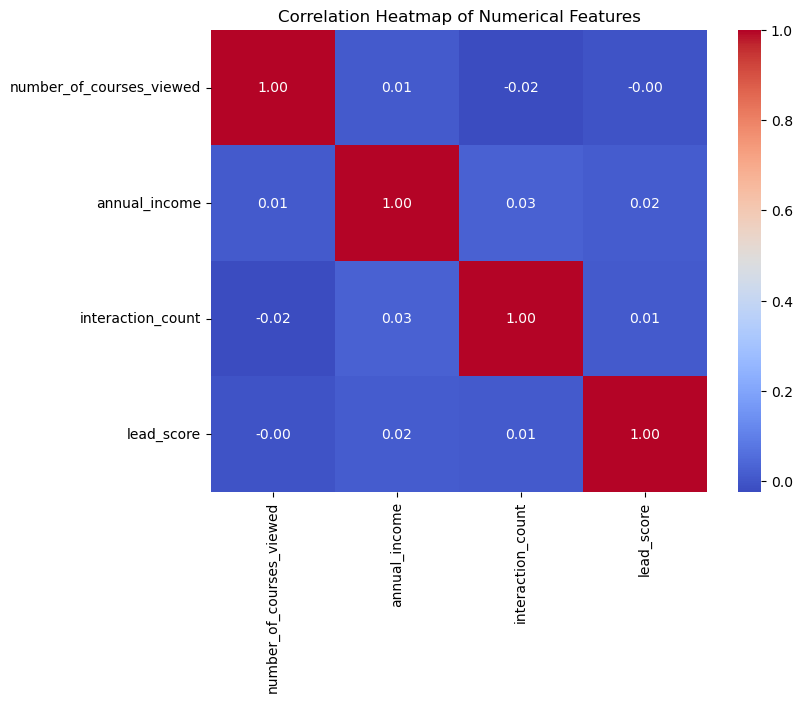

In [56]:
# Ensure plots show inside the notebook
%matplotlib inline  

import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix
correlation_matrix = df[numerical_no_target].corr()

# Create the heatmap
plt.figure(figsize=(8, 6))  # Optional: make the plot larger
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")

# Add a title
plt.title("Correlation Heatmap of Numerical Features")

# Force display
plt.show()

>### annual_income and interaction_count

In [57]:
print("interaction_count and lead_score:\t", correlation_matrix["interaction_count"]["lead_score"].item())
print("number_of_courses_viewed and lead_score:\t", correlation_matrix["number_of_courses_viewed"]["lead_score"].item())
print("number_of_courses_viewed and interaction_count:\t", correlation_matrix["number_of_courses_viewed"]["interaction_count"].item())
print("annual_income and interaction_count:\t", correlation_matrix["annual_income"]["interaction_count"].item())

interaction_count and lead_score:	 0.009888182496913131
number_of_courses_viewed and lead_score:	 -0.004878998354681276
number_of_courses_viewed and interaction_count:	 -0.023565222882888037
annual_income and interaction_count:	 0.02703647240481443
